In [1]:
import cv2
import matplotlib.pyplot as plt

def count_faces(image_path):
    """
    Counts the number of faces in an image using OpenCV's Haar Cascade classifier.

    Args:
        image_path (str): The path to the input image file.

    Returns:
        int: The number of faces detected in the image.
    """
    # Load the pre-trained Haar cascade classifier for face detection
    # OpenCV provides these XML files. We'll use a common one.
    # You might need to install `opencv-python` and download the cascade file.
    # For Colab, it's usually available directly through `cv2.data.haarcascades`.
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

    # Read the image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return 0

    # Convert the image to grayscale, as face detection works better on grayscale images
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect faces in the image
    # scaleFactor: Parameter specifying how much the image size is reduced at each image scale.
    # minNeighbors: Parameter specifying how many neighbors each candidate rectangle should have to retain it.
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    # Draw rectangles around the faces (optional, for visualization)
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2) # Blue rectangle

    # Display the image with detected faces
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Detected Faces: {len(faces)}")
    plt.axis('off')
    plt.show()

    return len(faces)


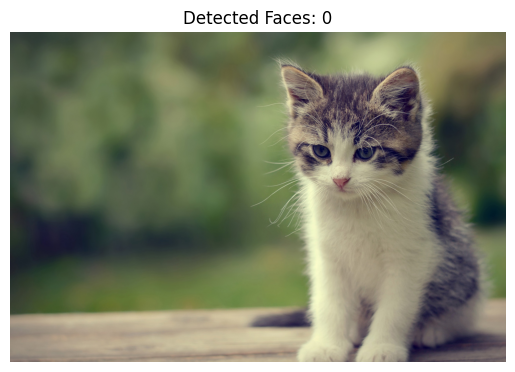

Number of faces detected in /content/cat.jpg: 0


In [2]:
# Call the function with your image file
image_file = '/content/cat.jpg'
num_faces = count_faces(image_file)
print(f"Number of faces detected in {image_file}: {num_faces}")
